# 02 Analysis and Visualization

Reads experiment outputs from notebook 01, computes statistical summaries,
and generates report-ready figures and tables.


## Cell 1 - Imports and path setup


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torchvision.datasets import Caltech101

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ha2_analysis import (
    bootstrap_accuracy_ci,
    build_paired_frame,
    mcnemar_test,
    select_case_indices,
    top_confusions,
)
from ha2_experiments import load_caltech_dataset, resolve_caltech_root

sns.set_theme(style="whitegrid")
print("Project root:", PROJECT_ROOT)


Project root: D:\code\HA2


## Cell 2 - Load config, metadata, and run-mode results


In [2]:
artifacts_root = PROJECT_ROOT / "artifacts"
config = json.loads((artifacts_root / "config_resolved.json").read_text(encoding="utf-8"))

class_names = json.loads((artifacts_root / "meta" / "class_names.json").read_text(encoding="utf-8"))

RUN_MODE = "full"  # smoke | full

metrics_path = artifacts_root / "results" / f"metrics_{RUN_MODE}.csv"
preds_path = artifacts_root / "results" / f"predictions_{RUN_MODE}.parquet"
a1_path = artifacts_root / "results" / f"a1_template_count_{RUN_MODE}.csv"
runtime_path = artifacts_root / "runtime" / f"runtime_{RUN_MODE}.csv"

metrics_df = pd.read_csv(metrics_path)
preds_df = pd.read_parquet(preds_path)
a1_df = pd.read_csv(a1_path)
runtime_df = pd.read_csv(runtime_path)

print("Loaded rows | metrics:", len(metrics_df), "preds:", len(preds_df), "a1:", len(a1_df))
display(metrics_df.head())


Loaded rows | metrics: 26 preds: 34708 a1: 60


,run_mode,model,exp,acc,num_samples,n_templates,agg,normalize,seed,variant,acc_std
0,full,ViT-B/32,B0_chance,0.010372,8677.0,0.0,none,False,3407.0,NaN,NaN
1,full,ViT-B/16,B0_chance,0.010372,8677.0,0.0,none,False,3407.0,NaN,NaN
2,full,ViT-B/32,B1_simple,0.875879,8677.0,1.0,feature_mean,True,3407.0,NaN,NaN
3,full,ViT-B/32,M1_ensemble_all,0.872882,8677.0,34.0,feature_mean,True,3407.0,NaN,NaN
4,full,ViT-B/16,B1_simple,0.883370,8677.0,1.0,feature_mean,True,3407.0,NaN,NaN


## Cell 3 - Build CI + McNemar stats (B1 vs M1 per model)


In [3]:
stats_rows = []
mcnemar_rows = []

for model_name in sorted(preds_df["model"].unique()):
    paired = build_paired_frame(preds_df, model_name)
    y_true = paired["label_id"].to_numpy(dtype=np.int64)

    ci_simple = bootstrap_accuracy_ci(
        y_true=y_true,
        y_pred=paired["pred_simple"].to_numpy(dtype=np.int64),
        n_boot=2000 if RUN_MODE == "smoke" else 5000,
        seed=3407,
    )
    ci_ens = bootstrap_accuracy_ci(
        y_true=y_true,
        y_pred=paired["pred_ens"].to_numpy(dtype=np.int64),
        n_boot=2000 if RUN_MODE == "smoke" else 5000,
        seed=3408,
    )

    stats_rows.append(
        {
            "run_mode": RUN_MODE,
            "model": model_name,
            "exp": "B1_simple",
            **ci_simple,
        }
    )
    stats_rows.append(
        {
            "run_mode": RUN_MODE,
            "model": model_name,
            "exp": "M1_ensemble_all",
            **ci_ens,
        }
    )

    mc = mcnemar_test(
        y_true=y_true,
        pred_a=paired["pred_simple"].to_numpy(dtype=np.int64),
        pred_b=paired["pred_ens"].to_numpy(dtype=np.int64),
    )
    mcnemar_rows.append(
        {
            "run_mode": RUN_MODE,
            "model": model_name,
            **mc,
        }
    )

ci_df = pd.DataFrame(stats_rows)
mc_df = pd.DataFrame(mcnemar_rows)

display(ci_df)
display(mc_df)


,run_mode,model,exp,acc,ci_low,ci_high,ci_half_width
0,full,ViT-B/16,B1_simple,0.883370,0.876570,0.890169,0.006800
1,full,ViT-B/16,M1_ensemble_all,0.887058,0.880258,0.893627,0.006684
2,full,ViT-B/32,B1_simple,0.875879,0.868733,0.882678,0.006972
3,full,ViT-B/32,M1_ensemble_all,0.872882,0.865737,0.879797,0.007030


,run_mode,model,b,c,chi2,p_value,n_discordant
0,full,ViT-B/16,254,286,1.779630,0.182195,540
1,full,ViT-B/32,322,296,1.011327,0.314585,618


## Cell 4 - Build report tables


In [4]:
table_main = (
    ci_df.pivot(index="model", columns="exp", values="acc")
    .reset_index()
    .rename_axis(None, axis=1)
)
table_main["delta_ens_minus_simple"] = table_main["M1_ensemble_all"] - table_main["B1_simple"]

# add CI string columns for readability
ci_fmt = {}
for _, r in ci_df.iterrows():
    ci_fmt[(r["model"], r["exp"])] = f"{r['acc']:.4f} [{r['ci_low']:.4f}, {r['ci_high']:.4f}]"

table_main["B1_simple_ci"] = [ci_fmt[(m, "B1_simple")] for m in table_main["model"]]
table_main["M1_ensemble_all_ci"] = [ci_fmt[(m, "M1_ensemble_all")] for m in table_main["model"]]

a1_summary = (
    a1_df.groupby(["model", "k"], as_index=False)
    .agg(acc_mean=("acc", "mean"), acc_std=("acc", "std"))
    .sort_values(["model", "k"])
)

print("Main table:")
display(table_main)
print("A1 summary:")
display(a1_summary.head(20))


Main table:


,model,B1_simple,M1_ensemble_all,delta_ens_minus_simple,B1_simple_ci,M1_ensemble_all_ci
0,ViT-B/16,0.883370,0.887058,0.003688,"0.8834 [0.8766, 0.8902]","0.8871 [0.8803, 0.8936]"
1,ViT-B/32,0.875879,0.872882,-0.002996,"0.8759 [0.8687, 0.8827]","0.8729 [0.8657, 0.8798]"


A1 summary:


,model,k,acc_mean,acc_std
0,ViT-B/16,1,0.883370,0.000000
1,ViT-B/16,2,0.888487,0.005299
2,ViT-B/16,4,0.887634,0.003988
3,ViT-B/16,8,0.888994,0.001834
4,ViT-B/16,16,0.888879,0.003142
5,ViT-B/16,34,0.887058,0.000000
6,ViT-B/32,1,0.875879,0.000000
7,ViT-B/32,2,0.874542,0.004474
8,ViT-B/32,4,0.872030,0.005400
9,ViT-B/32,8,0.872006,0.007249


## Cell 5 - Figure 1: Main bar with CI


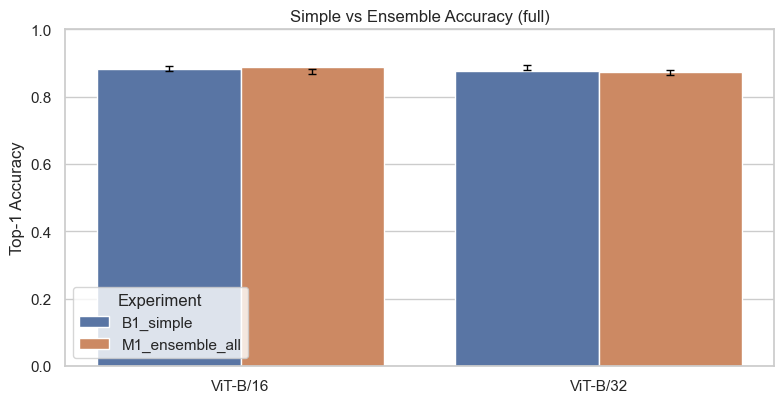

Saved: D:\code\HA2\artifacts\figures\fig_main_bar_ci_full.png


In [5]:
plot_df = ci_df[ci_df["exp"].isin(["B1_simple", "M1_ensemble_all"])].copy()
exp_order = ["B1_simple", "M1_ensemble_all"]

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=plot_df, x="model", y="acc", hue="exp", hue_order=exp_order, ax=ax, palette="deep")

# CI error bars manually
# Order in seaborn barplot: each x category expands by hue order
bars = ax.patches
for i, (_, row) in enumerate(plot_df.sort_values(["model", "exp"]).iterrows()):
    bar = bars[i]
    x = bar.get_x() + bar.get_width() / 2
    y = row["acc"]
    yerr_low = y - row["ci_low"]
    yerr_high = row["ci_high"] - y
    ax.errorbar(x, y, yerr=[[yerr_low], [yerr_high]], fmt="none", ecolor="black", capsize=3, lw=1)

ax.set_ylim(0, 1)
ax.set_title(f"Simple vs Ensemble Accuracy ({RUN_MODE})")
ax.set_ylabel("Top-1 Accuracy")
ax.set_xlabel("")
ax.legend(title="Experiment")
plt.tight_layout()

fig_path = artifacts_root / "figures" / f"fig_main_bar_ci_{RUN_MODE}.png"
plt.savefig(fig_path, dpi=180)
plt.show()
print("Saved:", fig_path)


## Cell 6 - Figure 2: Template count curve


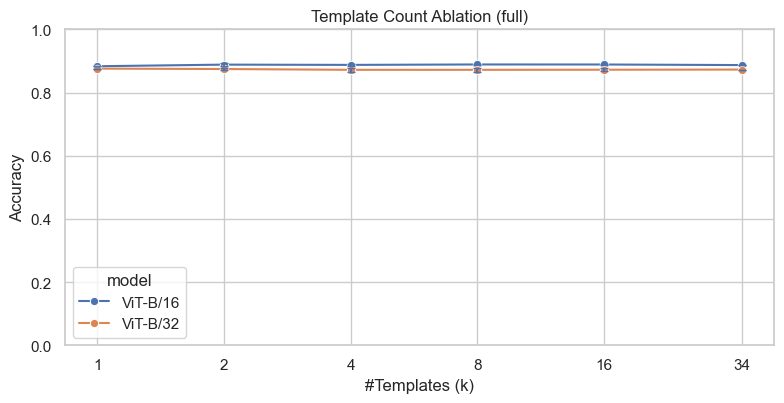

Saved: D:\code\HA2\artifacts\figures\fig_template_count_curve_full.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.lineplot(data=a1_summary, x="k", y="acc_mean", hue="model", marker="o", ax=ax)
for model_name, g in a1_summary.groupby("model"):
    ax.errorbar(g["k"], g["acc_mean"], yerr=g["acc_std"].fillna(0), fmt="none", capsize=3)

ax.set_xscale("log", base=2)
ax.set_xticks([1, 2, 4, 8, 16, 34])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylim(0, 1)
ax.set_title(f"Template Count Ablation ({RUN_MODE})")
ax.set_ylabel("Accuracy")
ax.set_xlabel("#Templates (k)")
plt.tight_layout()

fig_path = artifacts_root / "figures" / f"fig_template_count_curve_{RUN_MODE}.png"
plt.savefig(fig_path, dpi=180)
plt.show()
print("Saved:", fig_path)


## Cell 7 - Figure 3: Grouped ablations (A2/A3)


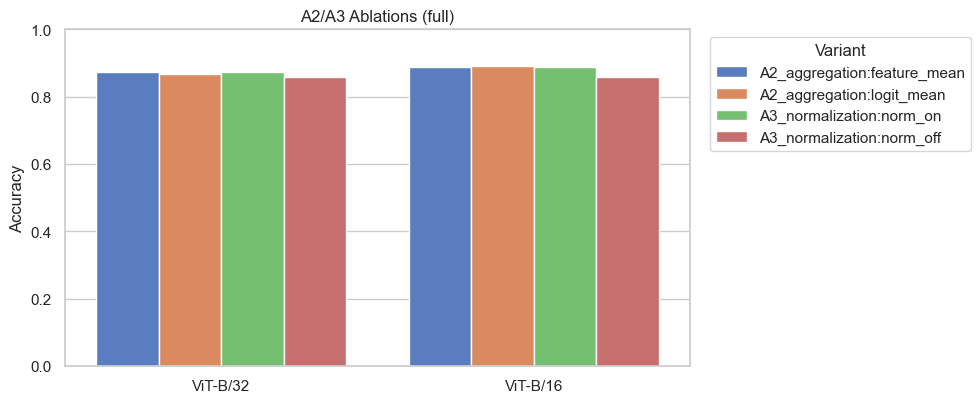

Saved: D:\code\HA2\artifacts\figures\fig_ablation_grouped_full.png


In [7]:
ab_df = metrics_df[metrics_df["exp"].isin(["A2_aggregation", "A3_normalization"])].copy()
ab_df["exp_variant"] = ab_df["exp"] + ":" + ab_df["variant"].astype(str)

fig, ax = plt.subplots(figsize=(10, 4.2))
sns.barplot(data=ab_df, x="model", y="acc", hue="exp_variant", ax=ax, palette="muted")
ax.set_ylim(0, 1)
ax.set_title(f"A2/A3 Ablations ({RUN_MODE})")
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
ax.legend(title="Variant", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

fig_path = artifacts_root / "figures" / f"fig_ablation_grouped_{RUN_MODE}.png"
plt.savefig(fig_path, dpi=180)
plt.show()
print("Saved:", fig_path)


## Cell 8 - Confusion summary and figure


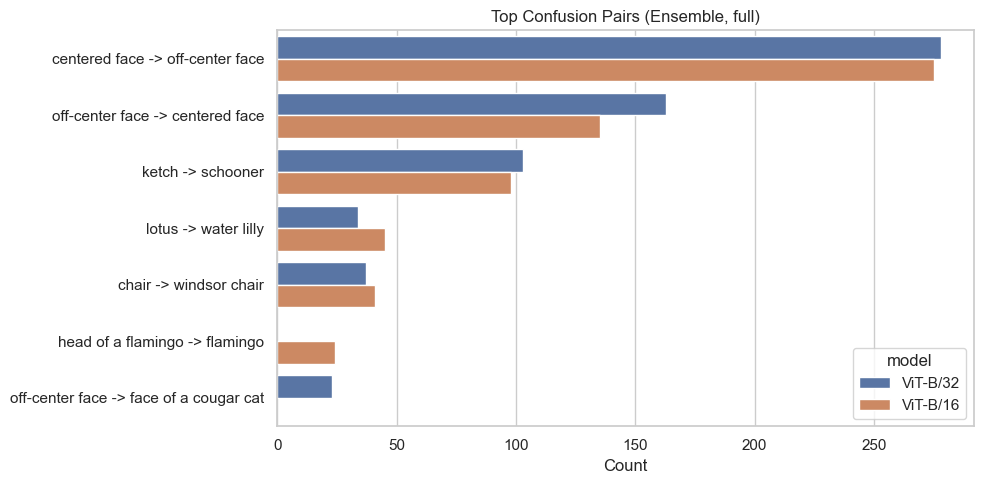

Saved: D:\code\HA2\artifacts\figures\fig_top_confusions_full.png


In [8]:
conf_rows = []
for model_name in sorted(preds_df["model"].unique()):
    paired = build_paired_frame(preds_df, model_name)
    topc = top_confusions(
        y_true=paired["label_id"].to_numpy(dtype=np.int64),
        y_pred=paired["pred_ens"].to_numpy(dtype=np.int64),
        top_k=12,
    )
    topc["model"] = model_name
    conf_rows.append(topc)

conf_df = pd.concat(conf_rows, ignore_index=True)
conf_df["gt_name"] = conf_df["gt"].map(lambda x: class_names[int(x)])
conf_df["pred_name"] = conf_df["pred"].map(lambda x: class_names[int(x)])
conf_df["pair"] = conf_df["gt_name"] + " -> " + conf_df["pred_name"]

fig, ax = plt.subplots(figsize=(10, 5))
show_df = conf_df.sort_values("count", ascending=False).head(12)
sns.barplot(data=show_df, x="count", y="pair", hue="model", ax=ax)
ax.set_title(f"Top Confusion Pairs (Ensemble, {RUN_MODE})")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()

fig_path = artifacts_root / "figures" / f"fig_top_confusions_{RUN_MODE}.png"
plt.savefig(fig_path, dpi=180)
plt.show()
print("Saved:", fig_path)


## Cell 9 - Prepare datasets for case visualization


In [9]:
# Use best model by ensemble accuracy for case visualization
best_model = (
    metrics_df[metrics_df["exp"] == "M1_ensemble_all"]
    .sort_values("acc", ascending=False)
    .iloc[0]["model"]
)
paired_best = build_paired_frame(preds_df, best_model)
improved_idx, failed_idx = select_case_indices(
    paired_best,
    n_improved=12,
    n_failed=12,
    seed=2026,
)

print("Best model:", best_model)
print("Improved cases:", len(improved_idx), "| Failed cases:", len(failed_idx))

data_root = Path(config["data_root"])
caltech_root = resolve_caltech_root(data_root)
dataset_raw = load_caltech_dataset(caltech_root, transform=None)


Best model: ViT-B/16
Improved cases: 12 | Failed cases: 12


## Cell 10 - Figure 4A: improved case grid


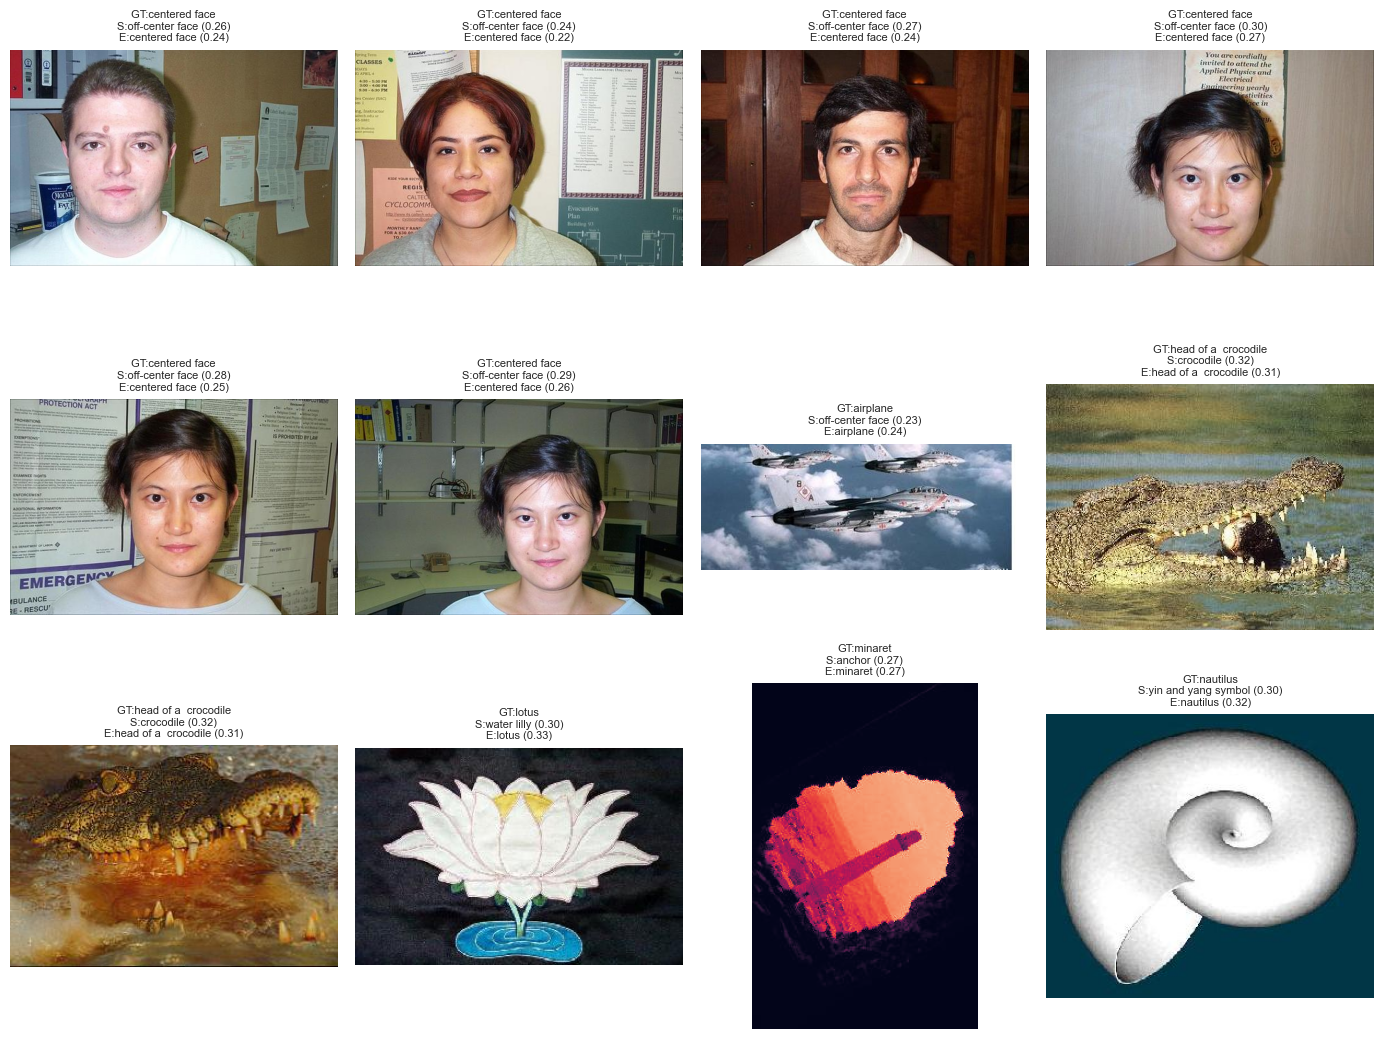

Saved: D:\code\HA2\artifacts\figures\fig_cases_improved_grid_full.png


In [10]:
def _get_pred_row(paired_df, idx):
    row = paired_df[paired_df["sample_index"] == idx].iloc[0]
    return row

n = min(12, len(improved_idx))
cols = 4
rows = int(np.ceil(max(n, 1) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.6 * rows))
axes = np.array(axes).reshape(rows, cols)

for i in range(rows * cols):
    ax = axes.ravel()[i]
    if i >= n:
        ax.axis("off")
        continue
    idx = int(improved_idx[i])
    img, _ = dataset_raw[idx]
    row = _get_pred_row(paired_best, idx)
    ax.imshow(img)
    title = (
        f"GT:{class_names[int(row['label_id'])]}\n"
        f"S:{class_names[int(row['pred_simple'])]} ({row['conf_simple']:.2f})\n"
        f"E:{class_names[int(row['pred_ens'])]} ({row['conf_ens']:.2f})"
    )
    ax.set_title(title, fontsize=8)
    ax.axis("off")

plt.tight_layout()
fig_path = artifacts_root / "figures" / f"fig_cases_improved_grid_{RUN_MODE}.png"
plt.savefig(fig_path, dpi=180)
plt.show()
print("Saved:", fig_path)


## Cell 11 - Figure 4B: still-failed case grid


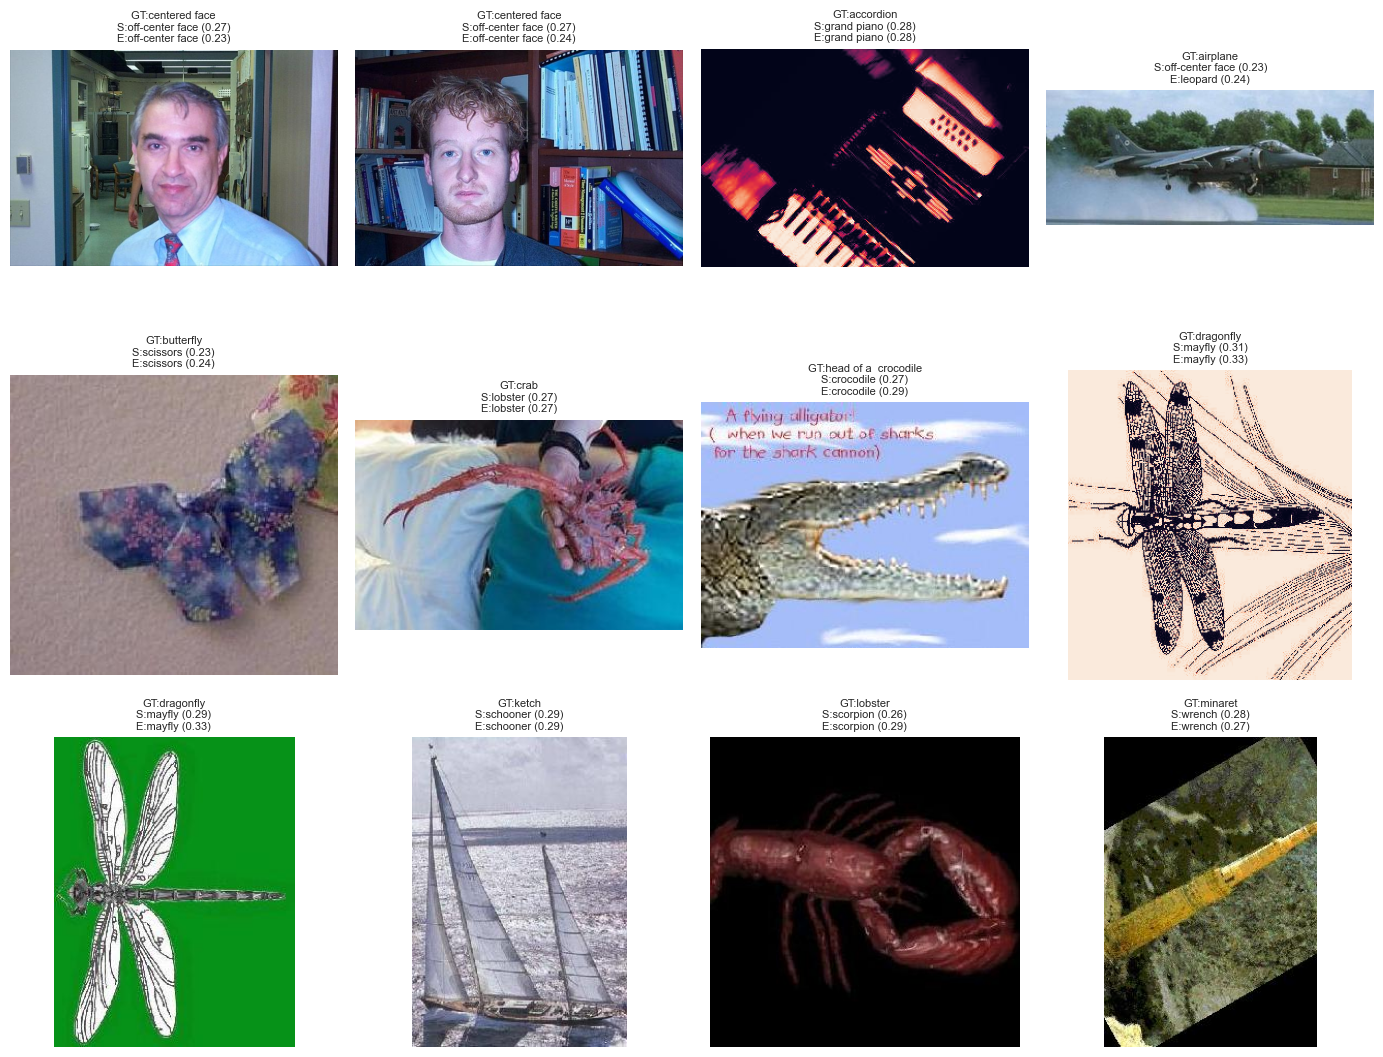

Saved: D:\code\HA2\artifacts\figures\fig_cases_failed_grid_full.png


In [11]:
n = min(12, len(failed_idx))
cols = 4
rows = int(np.ceil(max(n, 1) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.6 * rows))
axes = np.array(axes).reshape(rows, cols)

for i in range(rows * cols):
    ax = axes.ravel()[i]
    if i >= n:
        ax.axis("off")
        continue
    idx = int(failed_idx[i])
    img, _ = dataset_raw[idx]
    row = paired_best[paired_best["sample_index"] == idx].iloc[0]
    title = (
        f"GT:{class_names[int(row['label_id'])]}\n"
        f"S:{class_names[int(row['pred_simple'])]} ({row['conf_simple']:.2f})\n"
        f"E:{class_names[int(row['pred_ens'])]} ({row['conf_ens']:.2f})"
    )
    ax.imshow(img)
    ax.set_title(title, fontsize=8)
    ax.axis("off")

plt.tight_layout()
fig_path = artifacts_root / "figures" / f"fig_cases_failed_grid_{RUN_MODE}.png"
plt.savefig(fig_path, dpi=180)
plt.show()
print("Saved:", fig_path)


## Cell 12 - Save tables and report asset index


In [12]:
tables_root = artifacts_root / "tables"
tables_root.mkdir(parents=True, exist_ok=True)
results_root = artifacts_root / "results"

table_main_path = tables_root / f"table_main_{RUN_MODE}.csv"
a1_summary_path = tables_root / f"table_a1_summary_{RUN_MODE}.csv"
ci_path = results_root / f"ci_{RUN_MODE}.csv"
mc_path = results_root / f"mcnemar_{RUN_MODE}.csv"
conf_path = tables_root / f"table_confusions_{RUN_MODE}.csv"

table_main.to_csv(table_main_path, index=False)
a1_summary.to_csv(a1_summary_path, index=False)
ci_df.to_csv(ci_path, index=False)
mc_df.to_csv(mc_path, index=False)
conf_df.to_csv(conf_path, index=False)

asset_lines = [
    f"# Report Assets ({RUN_MODE})",
    "",
    "## Tables",
    f"- {table_main_path}",
    f"- {a1_summary_path}",
    f"- {ci_path}",
    f"- {mc_path}",
    f"- {conf_path}",
    "",
    "## Figures",
    f"- {artifacts_root / 'figures' / f'fig_main_bar_ci_{RUN_MODE}.png'}",
    f"- {artifacts_root / 'figures' / f'fig_template_count_curve_{RUN_MODE}.png'}",
    f"- {artifacts_root / 'figures' / f'fig_ablation_grouped_{RUN_MODE}.png'}",
    f"- {artifacts_root / 'figures' / f'fig_top_confusions_{RUN_MODE}.png'}",
    f"- {artifacts_root / 'figures' / f'fig_cases_improved_grid_{RUN_MODE}.png'}",
    f"- {artifacts_root / 'figures' / f'fig_cases_failed_grid_{RUN_MODE}.png'}",
]

asset_index_path = results_root / f"report_assets_index_{RUN_MODE}.md"
asset_index_path.write_text("\n".join(asset_lines) + "\n", encoding="utf-8")

print("Saved:", table_main_path)
print("Saved:", a1_summary_path)
print("Saved:", ci_path)
print("Saved:", mc_path)
print("Saved:", conf_path)
print("Saved:", asset_index_path)


Saved: D:\code\HA2\artifacts\tables\table_main_full.csv
Saved: D:\code\HA2\artifacts\tables\table_a1_summary_full.csv
Saved: D:\code\HA2\artifacts\results\ci_full.csv
Saved: D:\code\HA2\artifacts\results\mcnemar_full.csv
Saved: D:\code\HA2\artifacts\tables\table_confusions_full.csv
Saved: D:\code\HA2\artifacts\results\report_assets_index_full.md
